In [ ]:
import torch
torch.set_grad_enabled(False)
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate
from pathlib import Path
from copy import deepcopy
import os
import numpy as np

## Przygotowanie modelu

In [ ]:
run_dir = Path("runs/exp_01_20260331_170514/checkpoint_epoch_1_batch_0.pth") #runs/exp_01_20260309_132112")
config = OmegaConf.load(run_dir / "config.yaml")
# lateset "checkpoint*pth" in run_dir
checkpoint_path = sorted(run_dir.glob("checkpoint*.pth"), key=os.path.getctime)[-1]
print(f"Loading model from checkpoint: {checkpoint_path}")

model = instantiate(config.model).eval().to(config.training.device)
model.load_state_dict(torch.load(checkpoint_path, map_location=config.training.device))

Loading model from checkpoint: runs/exp_01_20260309_132112/checkpoint_epoch_0_batch_2000.pth


<All keys matched successfully>

## Dane wejściowe

In [16]:
n_eval_samples = 100
train_dataset = instantiate(config.data)
eval_dataset_config_with_augmentations = deepcopy(config.data)
eval_dataset_config_without_augmentations = deepcopy(config.data)

evaluation_indices = np.arange(config.data.indices, config.data.indices + n_eval_samples).tolist()
eval_dataset_config_with_augmentations.indices = evaluation_indices
eval_dataset_config_without_augmentations.indices = evaluation_indices

eval_dataset_config_without_augmentations.transforms = [transform_dict for transform_dict in eval_dataset_config_without_augmentations.transforms if transform_dict["_target_"] != "plbregression.dataset.AlbumentationImageTransformWrapper"]

no_augmentations_eval_dataset = instantiate(eval_dataset_config_without_augmentations)
with_augmentations_eval_dataset = instantiate(eval_dataset_config_with_augmentations)

augmentations_eval_batch = next(iter(torch.utils.data.DataLoader(with_augmentations_eval_dataset, batch_size=n_eval_samples, shuffle=False, num_workers=config.training.num_workers)))
no_augmentations_eval_batch = next(iter(torch.utils.data.DataLoader(no_augmentations_eval_dataset, batch_size=n_eval_samples, shuffle=False, num_workers=config.training.num_workers)))

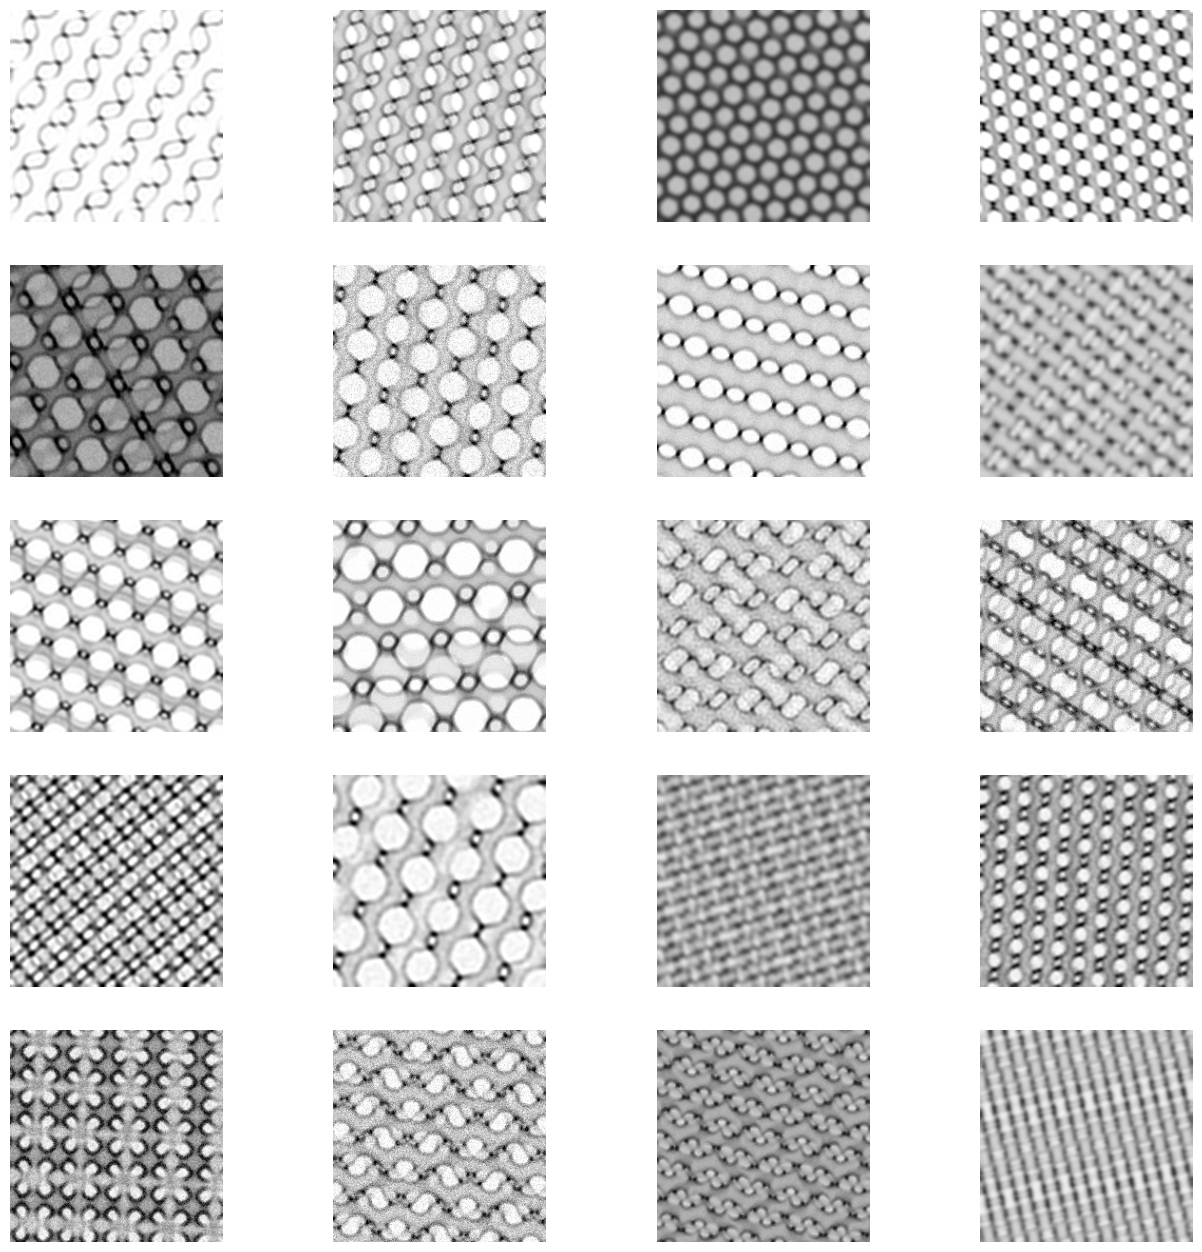

In [17]:
fig, axs = plt.subplots(5,4, figsize=(16, 16))
for i in range(20):
    ax = axs[i//4][i%4]
    ax.imshow(augmentations_eval_batch[0][i,0], vmin=0, vmax=1, cmap="gray")
    ax.axis("off")
# plt.suptitle("Augmented Images")


## Przewidywania

In [81]:
preds_augmentations_trainmode = model.train()(augmentations_eval_batch[0].to(config.training.device)).cpu().numpy()
preds_augmentations_evalmode = model.eval()(augmentations_eval_batch[0].to(config.training.device)).cpu().numpy()
preds_noaugmentations_trainmode = model.train()(no_augmentations_eval_batch[0].to(config.training.device)).cpu().numpy()
preds_noaugmentations_evalmode = model.eval()(no_augmentations_eval_batch[0].to(config.training.device)).cpu().numpy()



## Usuwanie normalizacji parametrów ilościowych i normalizacja wektora kierunkowego

In [58]:
hkl_to_unit_vector_transform = instantiate([transform_dict for transform_dict in config.data.params_transforms if transform_dict["_target_"] == "plbregression.dataset.HKLToUnitVector"][0])
params_normalizer = instantiate([transform_dict for transform_dict in config.data.params_transforms if transform_dict["_target_"] == "plbregression.dataset.ParamsNormalizer"][0])

In [86]:
preds_augmentations_trainmode = np.array([params_normalizer.inverse_transform(hkl_to_unit_vector_transform(pred)) for pred in preds_augmentations_trainmode])
preds_augmentations_evalmode = np.array([params_normalizer.inverse_transform(hkl_to_unit_vector_transform(pred)) for pred in preds_augmentations_evalmode])
preds_noaugmentations_trainmode = np.array([params_normalizer.inverse_transform(hkl_to_unit_vector_transform(pred)) for pred in preds_noaugmentations_trainmode])
preds_noaugmentations_evalmode = np.array([params_normalizer.inverse_transform(hkl_to_unit_vector_transform(pred)) for pred in preds_noaugmentations_evalmode])

gt_augmentations = np.array([params_normalizer.inverse_transform(params) for params in augmentations_eval_batch[1].numpy()])
gt_noaugmentations = np.array([params_normalizer.inverse_transform(params) for params in no_augmentations_eval_batch[1].numpy()])

# np.linalg.norm(gt_augmentations[:,2:], axis=1)

## Rezydua parametrów ilościowych i kierunku

In [88]:
param_residuals_augmentations_trainmode = preds_augmentations_trainmode[:,:2] - gt_augmentations[:,:2]
param_residuals_augmentations_evalmode = preds_augmentations_evalmode[:,:2] - gt_augmentations[:,:2]
param_residuals_noaugmentations_trainmode = preds_noaugmentations_trainmode[:,:2] - gt_noaugmentations[:,:2]
param_residuals_noaugmentations_evalmode = preds_noaugmentations_evalmode[:,:2] - gt_noaugmentations[:,:2]



In [90]:
direction_residual_augmentations_trainmode_deg = np.arctan(0.5*np.linalg.norm(preds_augmentations_trainmode[:,2:] - gt_augmentations[:,2:], axis=1)) * 180 / np.pi
direction_residual_augmentations_evalmode_deg = np.arctan(0.5*np.linalg.norm(preds_augmentations_evalmode[:,2:] - gt_augmentations[:,2:], axis=1)) * 180 / np.pi
direction_residual_noaugmentations_trainmode_deg = np.arctan(0.5*np.linalg.norm(preds_noaugmentations_trainmode[:,2:] - gt_noaugmentations[:,2:], axis=1)) * 180 / np.pi
direction_residual_noaugmentations_evalmode_deg = np.arctan(0.5*np.linalg.norm(preds_noaugmentations_evalmode[:,2:] - gt_noaugmentations[:,2:], axis=1)) * 180 / np.pi

Text(0.5, 0.98, 'Predicted vs GT parameters and residuals')

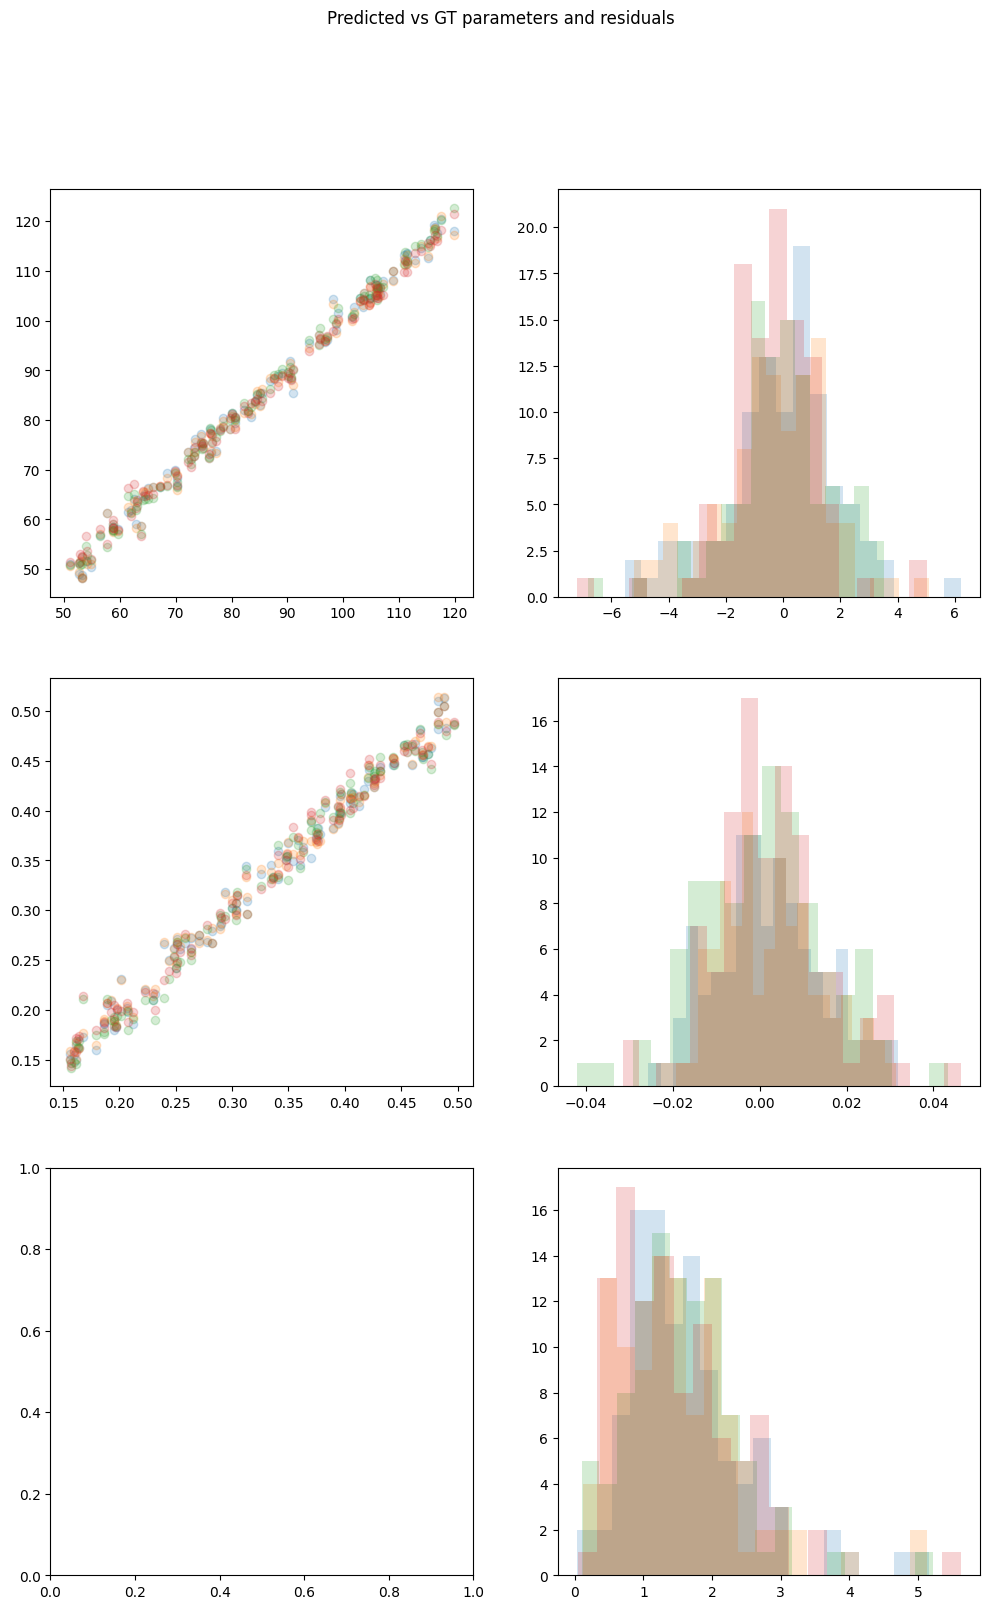

In [105]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 18))
# axs[0][0].axline([0,0], [1,1], c="0.25")
# axs[1][0].axline([0,0], [1,1], c="0.25")

axs[0][0].scatter(gt_augmentations[:,0], preds_augmentations_trainmode[:,0], alpha=0.2, label="aug, train mode");
axs[0][1].hist(param_residuals_augmentations_trainmode[:,0], bins=20, alpha=0.2, label="aug, train mode");
axs[1][0].scatter(gt_augmentations[:,1], preds_augmentations_trainmode[:,1], alpha=0.2, label="aug, train mode");
axs[1][1].hist(param_residuals_augmentations_trainmode[:,1], bins=20, alpha=0.2, label="aug, train mode");


axs[0][0].scatter(gt_augmentations[:,0], preds_augmentations_evalmode[:,0], alpha=0.2, label="aug, eval mode");
axs[0][1].hist(param_residuals_augmentations_evalmode[:,0], bins=20, alpha=0.2, label="aug, eval mode");
axs[1][0].scatter(gt_augmentations[:,1], preds_augmentations_evalmode[:,1], alpha=0.2, label="aug, eval mode");
axs[1][1].hist(param_residuals_augmentations_evalmode[:,1], bins=20, alpha=0.2, label="aug, eval mode");

axs[0][0].scatter(gt_noaugmentations[:,0], preds_noaugmentations_trainmode[:,0], alpha=0.2, label="no aug, train mode");
axs[0][1].hist(param_residuals_noaugmentations_trainmode[:,0], bins=20, alpha=0.2, label="no aug, train mode");
axs[1][0].scatter(gt_noaugmentations[:,1], preds_noaugmentations_trainmode[:,1], alpha=0.2, label="no aug, train mode");
axs[1][1].hist(param_residuals_noaugmentations_trainmode[:,1], bins=20, alpha=0.2, label="no aug, train mode");

axs[0][0].scatter(gt_noaugmentations[:,0], preds_noaugmentations_evalmode[:,0], alpha=0.2, label="no aug, eval mode");
axs[0][1].hist(param_residuals_noaugmentations_evalmode[:,0], bins=20, alpha=0.2, label="no aug, eval mode");
axs[1][0].scatter(gt_noaugmentations[:,1], preds_noaugmentations_evalmode[:,1], alpha=0.2, label="no aug, eval mode");
axs[1][1].hist(param_residuals_noaugmentations_evalmode[:,1], bins=20, alpha=0.2, label="no aug, eval mode");


axs[2][1].hist(direction_residual_augmentations_trainmode_deg, bins=20, alpha=0.2, label="aug, train mode");
axs[2][1].hist(direction_residual_augmentations_evalmode_deg, bins=20, alpha=0.2, label="aug, eval mode");
axs[2][1].hist(direction_residual_noaugmentations_trainmode_deg, bins=20, alpha=0.2, label="no aug, train mode");
axs[2][1].hist(direction_residual_noaugmentations_evalmode_deg, bins=20, alpha=0.2, label="no aug, eval mode");


fig.suptitle("Predicted vs GT parameters and residuals")